In [11]:
import pandas as pd
import numpy as np
import os

data = pd.read_csv("../data/raw/movies.csv")
data

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [12]:
df = data.copy()

# ML Inference on data

## ML Similarity Matrix

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

def build_movie_feature_matrix(df):
    df_model = data.copy().reset_index(drop=True)

    cat_cols = ["genre", "director", "writer", "star", "country", "rating", "company"]
    num_cols = ["year", "score", "votes", "budget", "gross", "runtime"]

    for col in cat_cols:
        df_model[col] = df_model[col].fillna("unknown").astype(str).str.lower()

    for col in num_cols:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")
        df_model[col] = df_model[col].fillna(df_model[col].median())

    # one-hot encode categoricals
    X_cat = pd.get_dummies(df_model[cat_cols], dummy_na=False)

    # scale numerics
    scaler = MinMaxScaler()
    X_num = pd.DataFrame(
        scaler.fit_transform(df_model[num_cols]),
        columns=num_cols,
        index=df_model.index
    )

    # combine
    X = pd.concat([X_cat, X_num], axis=1)

    return df_model, X

In [14]:
df_model, X = build_movie_feature_matrix(df)
sim_matrix = cosine_similarity(X)

similarity_matrix = pd.DataFrame(
    sim_matrix,
    index=df_model.index,
    columns=df_model.index
)

In [15]:
similarity_matrix

,0,1,2,3,4,5,6,7,8,9,...,7658,7659,7660,7661,7662,7663,7664,7665,7666,7667
0,1.000000,0.198796,0.132302,0.096686,0.218545,0.206925,0.231315,0.236970,0.086900,0.213051,...,0.314332,0.026307,0.079139,0.318050,0.071247,0.146492,0.045582,0.183766,0.196247,0.061173
1,0.198796,1.000000,0.198868,0.191897,0.324193,0.318856,0.328741,0.329925,0.187481,0.322527,...,0.299419,0.146511,0.176177,0.300934,0.171831,0.143990,0.157781,0.166516,0.173451,0.037953
2,0.132302,0.198868,1.000000,0.353738,0.219700,0.207792,0.358449,0.238789,0.471208,0.213227,...,0.193063,0.149306,0.200730,0.195844,0.314165,0.144920,0.168523,0.183142,0.195758,0.061884
3,0.096686,0.191897,0.353738,1.000000,0.341215,0.332231,0.217491,0.221017,0.336575,0.205715,...,0.187937,0.149241,0.318028,0.188352,0.187390,0.145416,0.292583,0.178428,0.188321,0.052703
4,0.218545,0.324193,0.219700,0.341215,1.000000,0.329809,0.344310,0.346636,0.201719,0.335354,...,0.310387,0.149108,0.315477,0.311210,0.184532,0.145518,0.292038,0.176500,0.185864,0.050129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,0.146492,0.143990,0.144920,0.145416,0.145518,0.144434,0.147115,0.147081,0.145827,0.145313,...,0.378425,0.254064,0.378025,0.379537,0.500599,1.000000,0.379568,0.502405,0.622468,0.257283
7664,0.045582,0.157781,0.168523,0.292583,0.292038,0.160311,0.168647,0.169428,0.164144,0.163498,...,0.271479,0.258001,0.513871,0.272391,0.392338,0.379568,1.000000,0.390593,0.392924,0.269285
7665,0.183766,0.166516,0.183142,0.178428,0.176500,0.170284,0.181877,0.183377,0.174410,0.174654,...,0.399813,0.259494,0.402292,0.401049,0.399939,0.502405,0.390593,1.000000,0.520650,0.275968
7666,0.196247,0.173451,0.195758,0.188321,0.185864,0.178103,0.192927,0.194918,0.183495,0.183494,...,0.405045,0.260604,0.408547,0.406951,0.524097,0.622468,0.392924,0.520650,1.000000,0.281208


## Build Ranking Dataset


In [16]:
def jaccard_text(a, b):
    sa = set(str(a).lower().split())
    sb = set(str(b).lower().split())
    return len(sa & sb) / max(1, len(sa | sb))

def relative_diff(a, b):
    """ Calculate the relative difference between two numbers """
    a = 0 if a is None or a == "" else float(a)
    b = 0 if b is None or b == "" else float(b)
    return abs(a - b) / max(1.0, max(abs(a), abs(b)))

def compute_features(movie_a, movie_b):
    return {
        "title_overlap": jaccard_text(movie_a["name"], movie_b["name"]),

        "year_diff": abs(int(movie_a["year"]) - int(movie_b["year"])),
        "score_diff": abs(float(movie_a["score"]) - float(movie_b["score"])),
        "votes_rel_diff": relative_diff(movie_a["votes"], movie_b["votes"]),
        "budget_rel_diff": relative_diff(movie_a["budget"], movie_b["budget"]),
        "gross_rel_diff": relative_diff(movie_a["gross"], movie_b["gross"]),
        "runtime_rel_diff": relative_diff(movie_a["runtime"], movie_b["runtime"]),

        "director_match": int(movie_a["director"] == movie_b["director"]),
        "writer_match": int(movie_a["writer"] == movie_b["writer"]),
        "star_match": int(movie_a["star"] == movie_b["star"]),
        "country_match": int(movie_a["country"] == movie_b["country"]),
        "company_match": int(movie_a["company"] == movie_b["company"]),
        "genre_match": int(movie_a["genre"] == movie_b["genre"]),
        "rating_match": int(movie_a["rating"] == movie_b["rating"]),
    }

In [17]:
# WHAT IS QID?
# Each movie_a is its own qid and is then tested against every other movie
'''
EXAMPLE:

movie_a 	movie_b 	features	label	qid
-----------------------------------------------
Shining	    Star Wars	   ...	      2	     0
Shining	    Airplane!	   ...	      0	     0
Star Wars	Shining	       ...	      2	     1
Star Wars	Airplane!	   ...	      1	     1
'''
def make_label(sim):
    """ Create buckets for how similar the movies are """
    if sim >= 0.90:
        return 4
    elif sim >= 0.80:
        return 3
    elif sim >= 0.65:
        return 2
    elif sim >= 0.50:
        return 1
    return 0


def build_dataset(df, similarity_matrix, top_k=50):
    X, y, qid = [], [], []
    n = len(df)

    for i in range(n):
        sims = similarity_matrix.iloc[i]
        candidate_idx = np.argsort(sims)[::-1]

        # skip self, take top_k
        candidate_idx = [j for j in candidate_idx if j != i][:top_k]

        for j in candidate_idx:
            sim = float(sims.iloc[j])
            features = compute_features(df.iloc[i], df.iloc[j])
            label = make_label(sim)

            X.append(features)
            y.append(label)
            qid.append(i)

    X = pd.DataFrame(X)
    y = np.array(y)
    qid = np.array(qid)

    return X, y, qid

## Train Test split


In [18]:
# Need to make my own function for train test split because of qid

def group_train_test_split(X, y, qid, test_size=0.2, random_state=42):
    np.random.seed(random_state)

    # unique queries (movies)
    unique_qids = np.unique(qid)

    # shuffle queries
    shuffled_qids = np.random.permutation(unique_qids)

    # split point
    split_idx = int(len(shuffled_qids) * (1 - test_size))

    train_qids = shuffled_qids[:split_idx]
    test_qids = shuffled_qids[split_idx:]

    # masks
    train_mask = np.isin(qid, train_qids)
    test_mask = np.isin(qid, test_qids)

    # split
    X_train = X[train_mask]
    y_train = y[train_mask]
    qid_train = qid[train_mask]

    X_test = X[test_mask]
    y_test = y[test_mask]
    qid_test = qid[test_mask]

    return X_train, X_test, y_train, y_test, qid_train, qid_test

In [19]:
# Get variables
X, y, qid = build_dataset(df, similarity_matrix)
X_train, X_test, y_train, y_test, qid_train, qid_test = group_train_test_split(X, y, qid)
THRESHOLD = 0.5

In [20]:
df_debug = pd.DataFrame({
    "qid": qid_train,
    "label": y_train
})

label_profile = df_debug.groupby("qid")["label"].value_counts().unstack(fill_value=0)
print(label_profile.head())
print(label_profile.describe())

label   0   1  2  3  4
qid                   
0      47   3  0  0  0
1      45   5  0  0  0
2      46   3  1  0  0
6      18  30  2  0  0
7      43   5  2  0  0
label            0            1            2            3            4
count  6134.000000  6134.000000  6134.000000  6134.000000  6134.000000
mean     31.670525    17.698891     0.503587     0.105804     0.021193
std      19.612025    19.234676     1.341521     0.475442     0.164145
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%      12.000000     1.000000     0.000000     0.000000     0.000000
50%      41.000000     8.000000     0.000000     0.000000     0.000000
75%      48.000000    37.000000     0.000000     0.000000     0.000000
max      50.000000    50.000000    18.000000     7.000000     2.000000


## XGBRanker

In [21]:
from xgboost import XGBRanker
import time

def train_xgb(xgb):

    # Training timer
    start_train = time.time()
    xgb.fit(X_train, y_train, qid=qid_train)
    xgb_train_time = time.time() - start_train
    print(f" Training time: {xgb_train_time:.2f} seconds\n")

    # Prediction timer
    start_pred = time.time()
    xgb_scores = xgb.predict(X_test)
    xgb_pred_time = time.time() -start_pred
    print(f"Prediction time: {xgb_pred_time:.4f} seconds\n")

    print(type(xgb_scores), xgb_scores.shape)
    print(xgb_scores[:10])

    return xgb_scores

xgb = XGBRanker(
        objective="rank:ndcg",
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
    )
xgb_scores = train_xgb(xgb)

 Training time: 6.97 seconds

Prediction time: 0.1098 seconds

<class 'numpy.ndarray'> (76700,)
[6.9106426 2.7778518 2.5191624 3.9182272 2.7925644 2.5593686 1.981323
 3.1726525 3.169964  3.832212 ]


## CATRanker

In [22]:
from catboost import CatBoostRanker

def train_cat(cat):

    start_train = time.time()
    # Training timer
    start_train = time.time()
    cat.fit(X_train, y_train, group_id=qid_train)
    cat_train_time = time.time() - start_train
    print(f" Training time: {cat_train_time:.2f} seconds\n")

    # Prediction timer
    start_pred = time.time()
    cat_scores = cat.predict(X_test)
    cat_pred_time = time.time() - start_pred
    print(f"Prediction time: {cat_pred_time:.4f} seconds\n")

    print(type(cat_scores), np.array(cat_scores).shape)
    print(np.array(cat_scores)[:10])

    return cat_scores

cat = CatBoostRanker(
    loss_function="YetiRank",
    iterations=200,
    learning_rate=0.1,
    random_seed=42,
    verbose=False,
)
cat_scores = train_cat(cat)

 Training time: 29.55 seconds

Prediction time: 0.0203 seconds

<class 'numpy.ndarray'> (76700,)
[9.53834116 4.77499939 4.70706262 5.81509516 4.70490517 5.51712501
 4.22456209 5.0183366  4.91127251 5.34140215]


## LGBMRanker


In [23]:
from lightgbm import LGBMRanker

def train_lgbm(lgbm):
    group_train = pd.Series(qid_train).value_counts().sort_index().to_list()
    group_test = pd.Series(qid_test).value_counts().sort_index().to_list()

    # Training timer
    start_train = time.time()
    lgbm.fit(
        X_train, y_train,
        group=group_train,
    )

    lgbm_train_time = time.time() - start_train
    print(f" Training time: {lgbm_train_time:.2f} seconds\n")

    # Prediction timer
    start_pred = time.time()
    lgbm_scores = lgbm.predict(X_test)
    lgbm_pred_time = time.time() - start_pred
    print(f"Prediction time: {lgbm_pred_time:.4f} seconds\n")

    print(type(lgbm_scores), lgbm_scores.shape)
    print(lgbm_scores[:10])

    return lgbm_scores

lgbm = LGBMRanker(
    objective="lambdarank",
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
)

lgbm_scores = train_lgbm(lgbm)

Prediction time: 0.2663 seconds

<class 'numpy.ndarray'> (76700,)
[8.58570588 2.94965156 3.00920065 4.6472847  3.62495233 2.92279458
 2.41468761 3.72151969 3.95493644 4.4785025 ]


## Results from training

In [24]:
def ndcg_at_k(y_true, y_score, qids, k=10):
    df_eval = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score,
        "qid": qids
    })

    ndcgs = []

    for _, group in df_eval.groupby("qid"):
        group = group.sort_values("y_score", ascending=False).head(k)
        gains = (2 ** group["y_true"].to_numpy() - 1)
        discounts = np.log2(np.arange(2, len(group) + 2))
        dcg = np.sum(gains / discounts)

        ideal = group.sort_values("y_true", ascending=False).head(k)
        ideal_gains = (2 ** ideal["y_true"].to_numpy() - 1)
        ideal_discounts = np.log2(np.arange(2, len(ideal) + 2))
        idcg = np.sum(ideal_gains / ideal_discounts)

        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return float(np.mean(ndcgs))

In [25]:
final_score = (
    0.4 * xgb_scores +
    0.4 * lgbm_scores +
    0.2 * cat_scores
)
print(f"XGB NDCG@10:", {ndcg_at_k(y_test, xgb_scores, qid_test, k=10)},
      "\nLGBM NDCG@10:", {ndcg_at_k(y_test, lgbm_scores, qid_test, k=10)},
      "\nCAT NDCG@10:", {ndcg_at_k(y_test, cat_scores, qid_test, k=10)},
      "\nCombined final score with xgb, lgbm and cat", {ndcg_at_k(y_test, final_score, qid_test)}
)


XGB NDCG@10: {0.8483850360022884} 
LGBM NDCG@10: {0.8502189458208049} 
CAT NDCG@10: {0.8455005211417664} 
Combined final score with xgb, lgbm and cat {0.8494292396486716}


### Plots

In [26]:
import matplotlib.pyplot as plt
def plot_importances(importances, title):
    feat_imp = pd.Series(importances, index=X_train.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(15)

    plt.figure()
    feat_imp.plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Importance")
    plt.show()

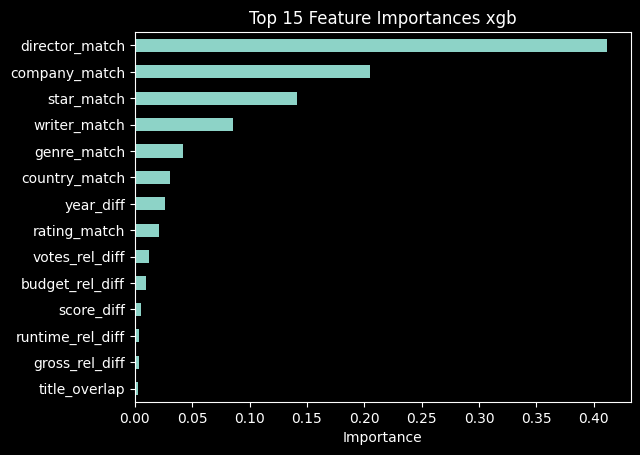

In [27]:
importances = xgb.feature_importances_
plot_importances(importances, "Top 15 Feature Importances xgb")

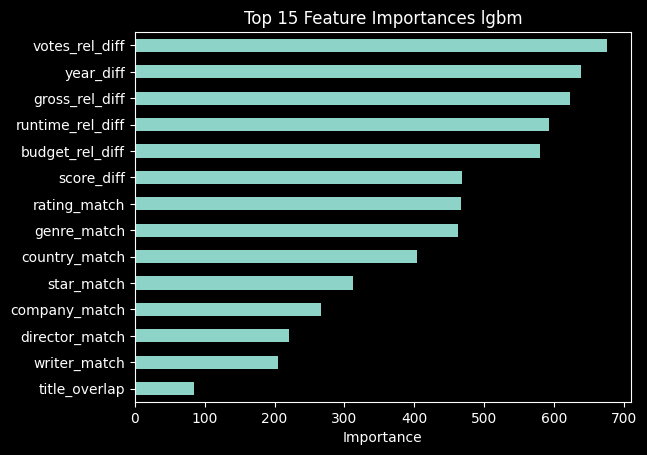

In [28]:
importances = lgbm.feature_importances_
plot_importances(importances, "Top 15 Feature Importances lgbm")

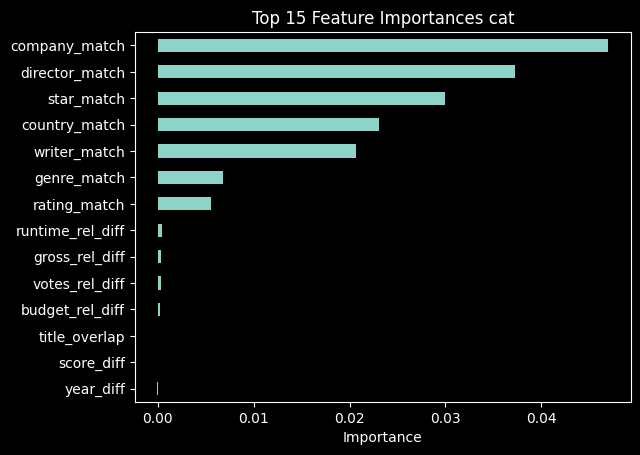

In [29]:
import catboost as cb

# 1. Create the Pool including the group/user identifier
# Replace 'user_id' with the actual name of your grouping column
train_pool = cb.Pool( data=X_train, label=y_train, group_id=qid_train)

# 2. Now calculate importance
importances = cat.get_feature_importance(data=train_pool,type='LossFunctionChange')

plot_importances(importances, "Top 15 Feature Importances cat")

## Pipeline

In [30]:
pipeline = False
if pipeline:
    print("Building dataset")
    X, y, qid = build_dataset(df, similarity_matrix)
    print("splitting X, y, qid")
    X_train, X_test, y_train, y_test, qid_train, qid_test = group_train_test_split(X, y, qid)

    xgb = XGBRanker(
            objective="rank:ndcg",
            n_estimators=200,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
        )

    cat = CatBoostRanker(
        loss_function="YetiRank",
        iterations=200,
        learning_rate=0.1,
        random_seed=42,
        verbose=False,
    )

    lgbm = LGBMRanker(
        objective="lambdarank",
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
    )

    print("training xgb")
    xgb_scores = train_xgb(xgb)
    print("training cat")
    cat_scores = train_cat(cat)
    print("training lgbm")
    lgbm_scores = train_lgbm(lgbm)


    final_score = (
        0.4 * xgb_scores +
        0.4 * lgbm_scores +
        0.2 * cat_scores
    )
    print(f"XGB NDCG@10:", {ndcg_at_k(y_test, xgb_scores, qid_test, k=10)},
          "\nLGBM NDCG@10:", {ndcg_at_k(y_test, lgbm_scores, qid_test, k=10)},
          "\nCAT NDCG@10:", {ndcg_at_k(y_test, cat_scores, qid_test, k=10)},
          "\nCombined final score with xgb, lgbm and cat", {ndcg_at_k(y_test, final_score, qid_test)}
    )

    train_pool = cb.Pool( data=X_train, label=y_train, group_id=qid_train)
    cat_importances = cat.get_feature_importance(data=train_pool,type='LossFunctionChange')
    lgbm_importances = lgbm.feature_importances_
    xgb_importances = xgb.feature_importances_

    print(f"\nXGB importances:{xgb_importances}\n LGBM importances:{lgbm_importances}\n Cat importances:{cat_importances}")

## Choose LGBM -> Tune Hyperparameters


Im going to choose LGBM because it seems to pick from a diverse range of attributes, and im not looking for perfect accuracy because then i would just use cosine similarity.

In [33]:
# -----------------------------
# 1) Split TRAIN into train/valid (avoid test leakage)
# -----------------------------
X_tr, X_val, y_tr, y_val, qid_tr, qid_val = group_train_test_split(X_train, y_train, qid_train)

In [39]:
import optuna
import lightgbm as lgbm

# 2. Define the objective function
group_tr = pd.Series(qid_tr).value_counts().sort_index().to_list()
group_val = pd.Series(qid_val).value_counts().sort_index().to_list()

def objective(trial):
    params = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_at": [10],
        "boosting_type": "gbdt",
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "random_state": 42,
        "n_jobs": -1,
    }

    ranker = LGBMRanker(**params)

    ranker.fit(
        X_tr,
        y_tr,
        group=group_tr,
        eval_set=[(X_val, y_val)],
        eval_group=[group_val],
        eval_at=[10],
        callbacks=[lgbm.early_stopping(30, verbose=False)]
    )

    val_scores = ranker.predict(X_val)
    return ndcg_at_k(y_val, val_scores, qid_val, k=10)

# 3. Create a study and optimize
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best validation NDCG@10:", study.best_value)

Best params: {'lambda_l1': 1.053597845807078e-08, 'lambda_l2': 0.0014506475814998628, 'num_leaves': 251, 'feature_fraction': 0.8607577600411263, 'bagging_fraction': 0.877718458300639, 'bagging_freq': 6, 'learning_rate': 0.1948152926265546, 'n_estimators': 393}
Best validation NDCG@10: 0.8242609213781878


In [45]:
best_params = study.best_params.copy()
best_params.update({
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_at": [10],
    "random_state": 42,
    "n_jobs": -1,
})

group_train = pd.Series(qid_train).value_counts().sort_index().to_list()

best_lgbm = LGBMRanker(**best_params)

start_train = time.time()
best_lgbm.fit(X_train, y_train, group=group_train)
train_time = time.time() - start_train

start_pred = time.time()
test_scores = best_lgbm.predict(X_test)
pred_time = time.time() - start_pred

k = 10
best_ndcg_10 = ndcg_at_k(y_test, test_scores, qid_test, k=k)
print("\nTest NDCG@10:", best_ndcg_10)
print(f"Train time: {train_time} - Test time: {pred_time}")



Test NDCG@10: 0.8542720355890197
Train time: 24.37029790878296 - Test time: 1.0567419528961182


## Mlflow save model

MLFlow is being used here for reproducability for the optimized hyperparameter set. It will save all data on the best model and set it up to be containerized

In [52]:
import mlflow.lightgbm
import os

# -----------------------------
# 4) MLflow logging (project-root mlruns)
# -----------------------------
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
mlflow.set_experiment("Movie Recommendation - LGBM")

with mlflow.start_run():
    # log params + threshold
    mlflow.log_params(best_params)
    mlflow.log_param("test_ndcg", best_ndcg_10)

    # log timing + metrics
    mlflow.log_metric("train_time", train_time)
    mlflow.log_metric("pred_time", pred_time)

    # save model
    mlflow.lightgbm.log_model(lgb_model=lgbm, artifact_path="model")


2026/04/08 17:47:46 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## LLM

IDEAS: \
turning user prompts into filters: “I want a dark sci fi movie from the 90s with a strong female lead” \
generating explanations “Recommended because it shares a director, tone, and era with The Shining” \
cold-start conversational search \
summarizing why top 5 recommendations differ \
extracting structured features from messy text fields like plot summaries or reviews